In [2]:
import numpy as np
import struct
import matplotlib.pyplot as plt


def load_images(filename):
    with open(filename, 'rb') as f:
        magic, size = struct.unpack(">II", f.read(8))
        rows, cols = struct.unpack(">II", f.read(8))

        data = np.fromfile(f, dtype = np.uint8)
        data = data.reshape(size, rows, cols)

        return data
    
images = load_images("train-images-idx3-ubyte")

print(images.shape)

(60000, 28, 28)


In [3]:
def load_labels(filename):
    with open(filename, 'rb') as f:
        magic, size = struct.unpack(">II", f.read(8))
        labels = np.fromfile(f, dtype = np.uint8, count=size)
        return labels

labels = load_labels("train-labels-idx1-ubyte")

print(labels.shape)
print(labels[:10])

(60000,)
[5 0 4 1 9 2 1 3 1 4]


Text(0.5, 1.0, 'Label: 5')

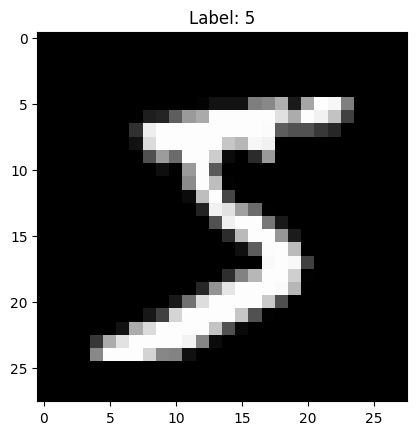

In [4]:
plt.imshow(images[0], cmap='gray')
plt.title(f"Label: {labels[0]}")

In [5]:
X = images.reshape(60000, 28*28)
X.shape

(60000, 784)

In [6]:
X = X/255.0

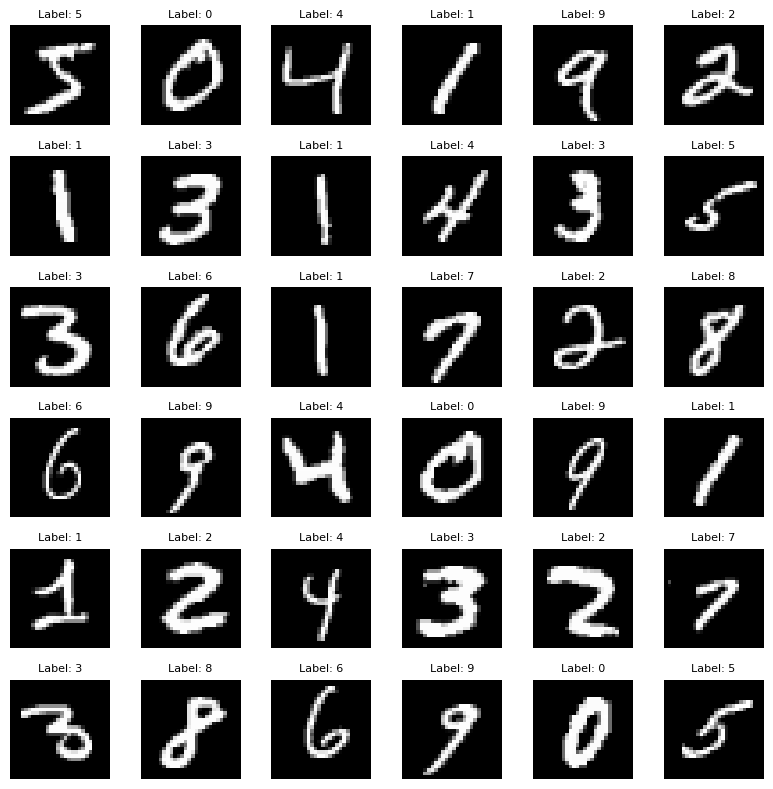

In [7]:
fig, ax = plt.subplots(6, 6, figsize =(8, 8))
for i, ax in enumerate(ax.flat):
    ax.imshow(X[i].reshape(28, 28), cmap='gray')
    ax.set_title(f"Label: {labels[i]}", fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [8]:
X_train = X[:50000]
y_train = labels[:50000]

X_test = X[50000:]
y_test = labels[50000:]

In [9]:
def one_hot(y, num_classes=10):
    return np.eye(num_classes)[y]


Y_train = one_hot(y_train)
Y_test = one_hot(y_test)

In [10]:
input_size = 784
hidden_size = 64
output_size = 10

In [13]:
def relu(x):
    return np.maximum(0, x)


def softmax(x):
    exp = np.exp(x - np.max(x, axis = 1, keepdims = True))
    return exp/ np.sum(exp, axis = 1, keepdims = True)


def compute_loss(Y_pred, Y_true):
    return -np.mean(np.sum(Y_true * np.log(Y_pred + 1e-8), axis =1))

In [12]:
np.random.seed(42)

W1 = np.random.randn(input_size, hidden_size) * 0.01
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size) * 0.01
b2 = np.zeros((1, output_size))

In [14]:
Z1 = X_train @ W1 + b1
A1 = relu(Z1)

Z2 = A1 @ W2 + b2
Y_pred = softmax(Z2)

In [15]:
loss = compute_loss(Y_pred, Y_train)
loss

np.float64(2.3026802115722314)

In [51]:
epochs = 2000
learning_rate = 0.1
for epoch in range(epochs):

    #Forward
    Z1 = X_train @ W1 + b1
    A1 = relu(Z1)
    Z2 = A1 @ W2 + b2
    Y_pred = softmax(Z2)

    # Loss
    loss = compute_loss(Y_pred, Y_train)

    # Backward
    dZ2 = Y_pred - Y_train
    dW2 = A1.T @ dZ2 / X_train.shape[0]
    db2 = np.sum(dZ2, axis=0, keepdims=True) / X_train.shape[0]

    dA1 = dZ2 @ W2.T
    dZ1 = dA1 *  (Z1 > 0)

    dW1 = X_train.T @ dZ1 / X_train.shape[0]
    db1 = np.sum(dZ1, axis =0, keepdims=True) / X_train.shape[0]

    # Update
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    if epoch % 1 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

Epoch 0, Loss: 0.0493
Epoch 1, Loss: 0.0493
Epoch 2, Loss: 0.0493
Epoch 3, Loss: 0.0493
Epoch 4, Loss: 0.0493
Epoch 5, Loss: 0.0493
Epoch 6, Loss: 0.0493
Epoch 7, Loss: 0.0493
Epoch 8, Loss: 0.0493
Epoch 9, Loss: 0.0493
Epoch 10, Loss: 0.0493
Epoch 11, Loss: 0.0492
Epoch 12, Loss: 0.0492
Epoch 13, Loss: 0.0492
Epoch 14, Loss: 0.0492
Epoch 15, Loss: 0.0492
Epoch 16, Loss: 0.0492
Epoch 17, Loss: 0.0492
Epoch 18, Loss: 0.0492
Epoch 19, Loss: 0.0492
Epoch 20, Loss: 0.0492
Epoch 21, Loss: 0.0492
Epoch 22, Loss: 0.0492
Epoch 23, Loss: 0.0492
Epoch 24, Loss: 0.0492
Epoch 25, Loss: 0.0492
Epoch 26, Loss: 0.0492
Epoch 27, Loss: 0.0492
Epoch 28, Loss: 0.0492
Epoch 29, Loss: 0.0492
Epoch 30, Loss: 0.0492
Epoch 31, Loss: 0.0492
Epoch 32, Loss: 0.0492
Epoch 33, Loss: 0.0491
Epoch 34, Loss: 0.0491
Epoch 35, Loss: 0.0491
Epoch 36, Loss: 0.0491
Epoch 37, Loss: 0.0491
Epoch 38, Loss: 0.0491
Epoch 39, Loss: 0.0491
Epoch 40, Loss: 0.0491
Epoch 41, Loss: 0.0491
Epoch 42, Loss: 0.0491
Epoch 43, Loss: 0.049

KeyboardInterrupt: 

In [52]:
y_pred = np.argmax(Y_pred, axis = 1)
y_true = np.argmax(Y_train, axis = 1)

In [53]:
def accuracy_test(preds, trues):
    return np.mean(preds == trues)

In [54]:
accuracy =  accuracy_test(y_pred, y_true)
print(f"Training Accuracy: {accuracy}")

Training Accuracy: 0.98754


In [55]:
Z1_test = X_test @ W1 + b1
A1_test = relu(Z1_test)

Z2_test = A1_test @ W2 + b2
Y_test_pred = softmax(Z2_test)

In [56]:
y_test_pred = np.argmax(Y_test_pred, axis = 1)

In [58]:
y_test_true = np.argmax(Y_test, axis = 1)

In [59]:
accuracy = accuracy_test(y_test_pred, y_test_true)
accuracy

np.float64(0.9722)

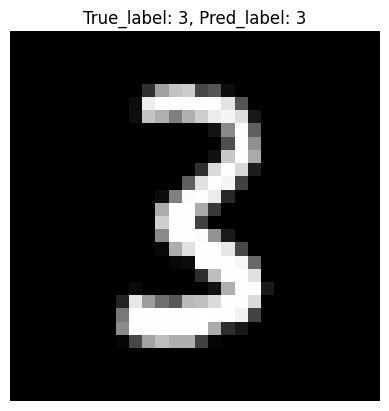

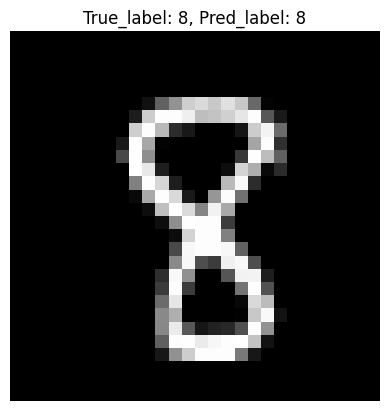

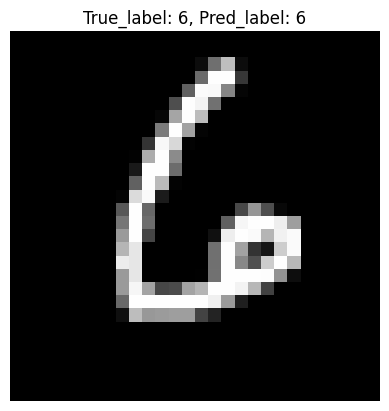

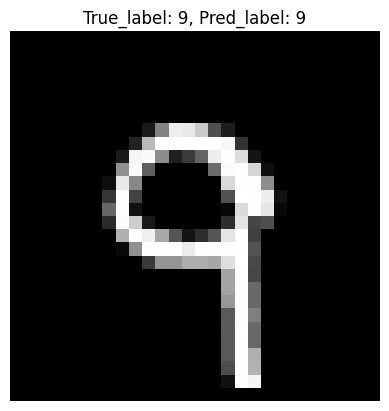

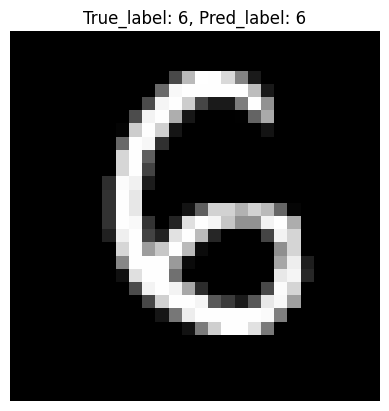

In [65]:
for i in range(5):
    fig, ax = plt.subplots()
    ax.imshow(X_test[i].reshape(28,28), cmap = 'gray')
    ax.set_title(f"True_label: {y_test_true[i]}, Pred_label: {y_test_pred[i]}")
    ax.axis("off")

In [68]:
cm = np.zeros((10,10), dtype=int)

for i in range(len(y_test_true)):
    true = int(y_test_true[i])
    pred = int(y_test_pred[i])
    cm[true, pred] += 1

In [69]:
cm

array([[ 979,    0,    3,    1,    0,    0,    1,    1,    1,    5],
       [   0, 1054,    3,    1,    0,    0,    0,    2,    4,    0],
       [   2,    4,  962,    4,    1,    1,    0,    8,    7,    1],
       [   1,    1,    6,  994,    1,   14,    0,    3,    6,    4],
       [   0,    5,    3,    0,  958,    1,    1,    1,    0,   14],
       [   1,    1,    6,   14,    4,  868,   10,    1,    6,    4],
       [   4,    0,    1,    0,    2,    3,  955,    0,    2,    0],
       [   1,    5,    6,    4,    3,    0,    0, 1064,    0,    7],
       [   2,    8,    5,    7,    1,    6,    3,    2,  967,    8],
       [   2,    2,    0,    4,   12,    5,    0,    7,    8,  921]])

In [71]:
cm_norm = cm / cm.sum(axis=1, keepdims=True)


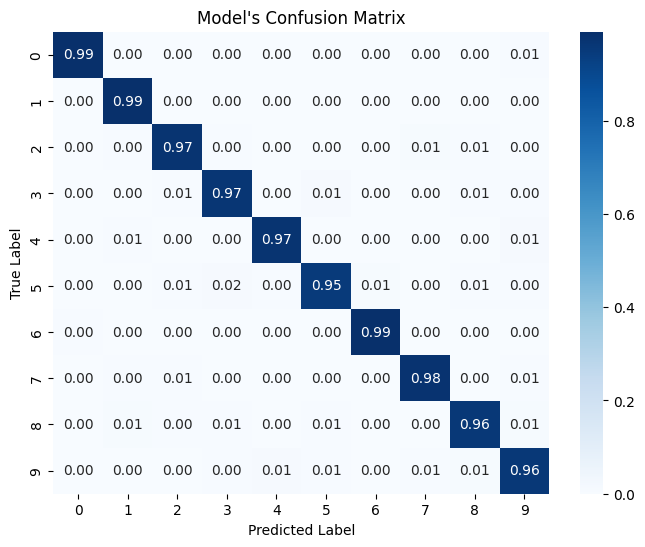

In [74]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(cm_norm, annot=True, cmap='Blues', fmt=".2f")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Model's Confusion Matrix")
plt.show()

In [75]:
errors = np.where(y_test_pred != y_test_true)[0]
print(errors[:10])

[ 86  91 120 212 239 246 320 329 340 359]


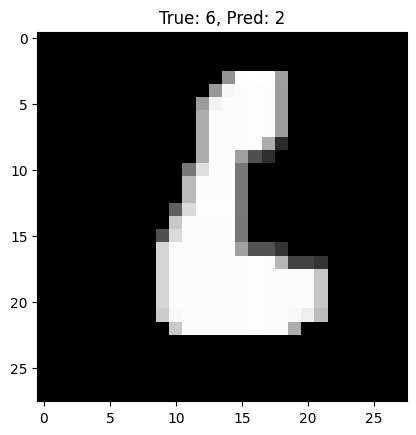

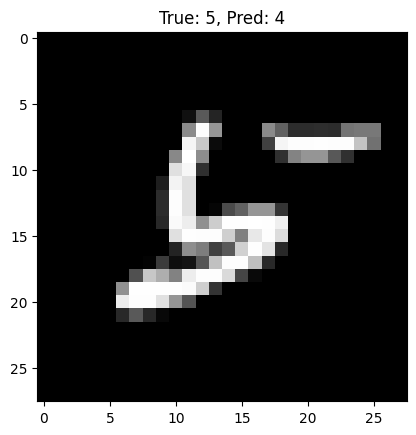

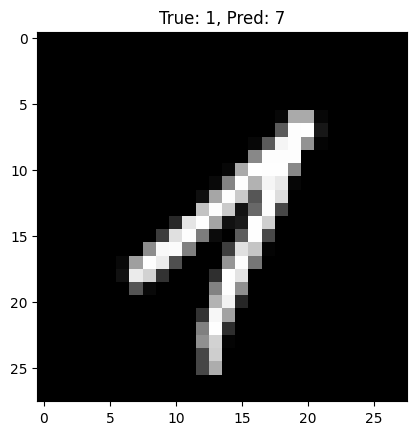

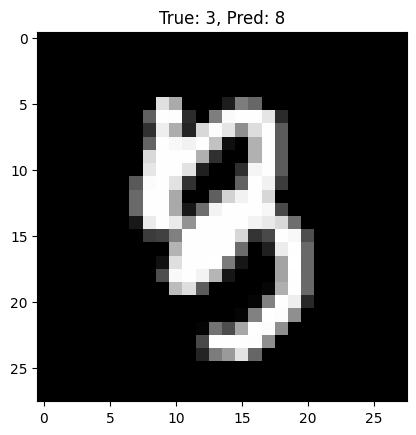

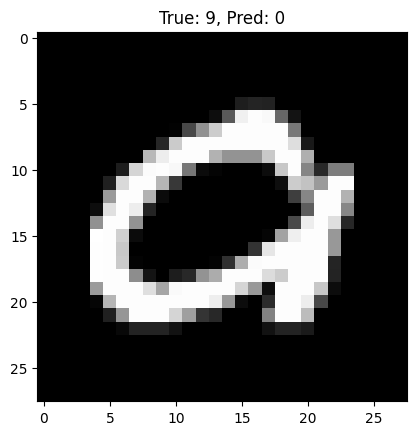

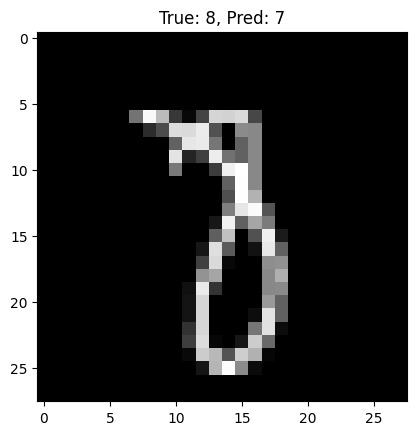

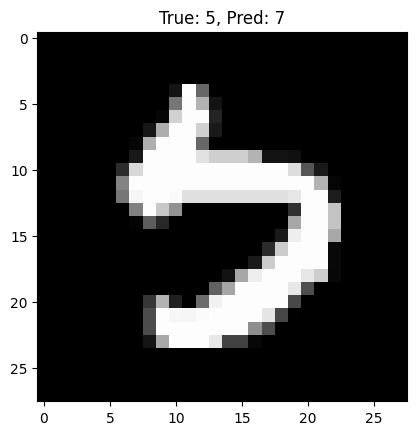

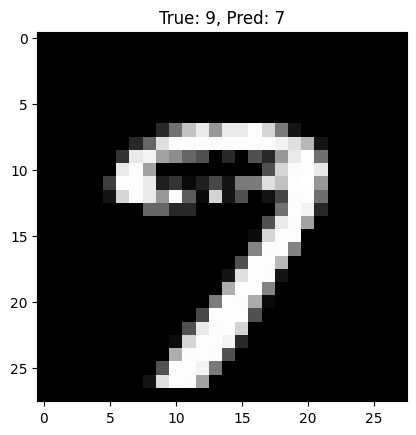

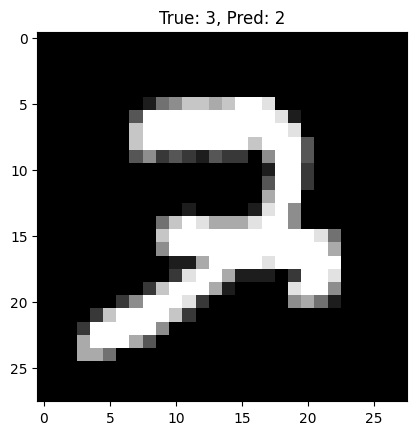

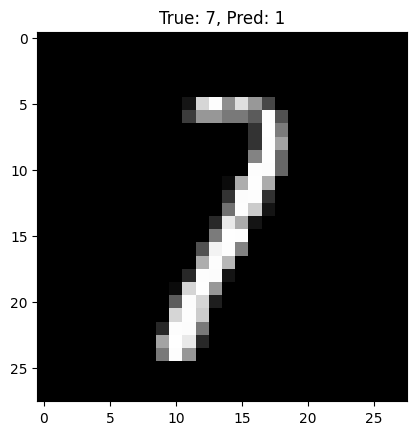

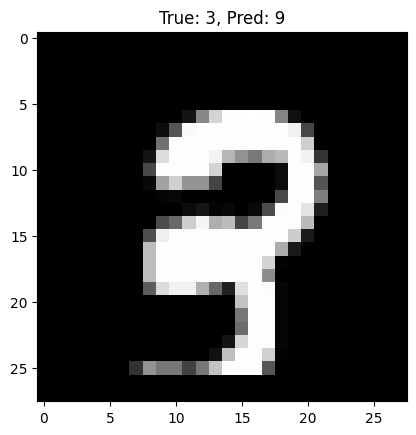

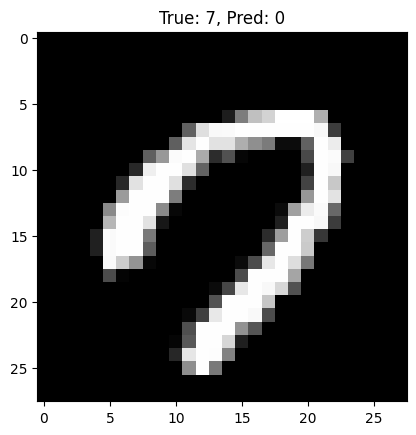

KeyboardInterrupt: 

In [81]:
for i in list(errors):
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"True: {y_test_true[i]}, Pred: {y_test_pred[i]}")
    plt.show()

In [89]:
errors2 = []

for i in range(len(y_test_true)):
    if y_test_pred[i] != y_test_true[i]:
        errors2.append((int(y_test_true[i]), int(y_test_pred[i])))

In [90]:
errors2

[(6, 2),
 (5, 4),
 (1, 7),
 (3, 8),
 (9, 0),
 (8, 7),
 (5, 7),
 (9, 7),
 (3, 2),
 (7, 1),
 (3, 9),
 (7, 0),
 (9, 4),
 (3, 9),
 (9, 5),
 (9, 3),
 (7, 1),
 (3, 9),
 (2, 8),
 (3, 8),
 (8, 3),
 (9, 8),
 (3, 5),
 (5, 6),
 (6, 0),
 (1, 2),
 (8, 7),
 (5, 3),
 (8, 3),
 (9, 8),
 (8, 9),
 (5, 3),
 (9, 4),
 (4, 5),
 (3, 5),
 (8, 6),
 (7, 2),
 (3, 5),
 (9, 4),
 (9, 4),
 (7, 1),
 (4, 2),
 (7, 9),
 (9, 4),
 (0, 2),
 (6, 8),
 (1, 3),
 (4, 9),
 (3, 9),
 (2, 7),
 (5, 2),
 (4, 9),
 (5, 9),
 (2, 1),
 (4, 9),
 (2, 7),
 (7, 4),
 (5, 3),
 (3, 5),
 (5, 4),
 (9, 8),
 (3, 5),
 (9, 7),
 (4, 2),
 (3, 5),
 (6, 4),
 (2, 8),
 (8, 9),
 (8, 9),
 (0, 6),
 (9, 7),
 (3, 5),
 (5, 4),
 (2, 1),
 (4, 9),
 (4, 9),
 (2, 3),
 (2, 3),
 (6, 0),
 (7, 9),
 (9, 8),
 (9, 8),
 (2, 1),
 (7, 2),
 (5, 3),
 (8, 2),
 (2, 8),
 (8, 2),
 (2, 0),
 (2, 8),
 (5, 6),
 (2, 8),
 (2, 9),
 (5, 3),
 (5, 6),
 (1, 8),
 (5, 9),
 (3, 2),
 (9, 0),
 (6, 0),
 (5, 8),
 (4, 9),
 (5, 8),
 (3, 7),
 (6, 5),
 (7, 9),
 (9, 7),
 (5, 8),
 (9, 7),
 (9, 5),
 (7, 2),
 

In [93]:
confusion_pairs = {}

for true, pred in errors2:
    pair = (true, pred)

    if pair not in confusion_pairs:
        confusion_pairs[pair] = 0
    confusion_pairs[pair] += 1

In [94]:
sorted_confusions = sorted(confusion_pairs.items(), key=lambda x:x[1], reverse=True)

for (true, pred), count in sorted_confusions[:10]:
    print(f"{true}<>{pred}: {count}")

3<>5: 14
5<>3: 14
4<>9: 14
9<>4: 12
5<>6: 10
9<>8: 8
8<>9: 8
2<>7: 8
8<>1: 8
9<>7: 7
